In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
df = pd.read_csv("delhi_aqi.csv")


In [3]:
df.head()


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [4]:
df.tail()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
556,2023-01-24 04:00:00,1762.39,4.64,37.01,33.26,30.52,231.15,289.84,6.27
557,2023-01-24 05:00:00,1735.69,6.82,34.96,46.49,34.33,225.08,280.52,9.12
558,2023-01-24 06:00:00,1922.61,8.16,40.10,56.51,43.39,242.49,296.07,12.54
559,2023-01-24 07:00:00,1361.85,9.05,52.78,71.53,100.14,165.67,191.82,7.47
560,2023-01-24 08:00:00,1134.87,8.61,56.89,80.11,110.63,123.76,140.26,5.51


In [6]:
df.shape

(561, 9)

In [7]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


In [9]:
df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [11]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [12]:
df['date'] = pd.to_datetime(df['date'])


In [13]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month


In [14]:
df.describe()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,Year,Month
count,561,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.0,561.0
mean,2023-01-12 16:00:00,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062,2023.0,1.0
min,2023-01-01 00:00:00,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000,2023.0,1.0
25%,2023-01-06 20:00:00,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000,2023.0,1.0
50%,2023-01-12 16:00:00,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000,2023.0,1.0
75%,2023-01-18 12:00:00,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000,2023.0,1.0
max,2023-01-24 08:00:00,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000,2023.0,1.0
std,NaN,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094,0.0,0.0


In [17]:
df['date'] = pd.to_datetime(df['date'])

In [18]:
df['AQI_Proxy'] = (df['pm2_5'] * 0.6) + (df['pm10'] * 0.4)

In [19]:
df[['date', 'AQI_Proxy']].head()

,date,AQI_Proxy
0,2023-01-01 00:00:00,179.430
1,2023-01-01 01:00:00,194.136
2,2023-01-01 02:00:00,236.422
3,2023-01-01 03:00:00,273.388
4,2023-01-01 04:00:00,288.936


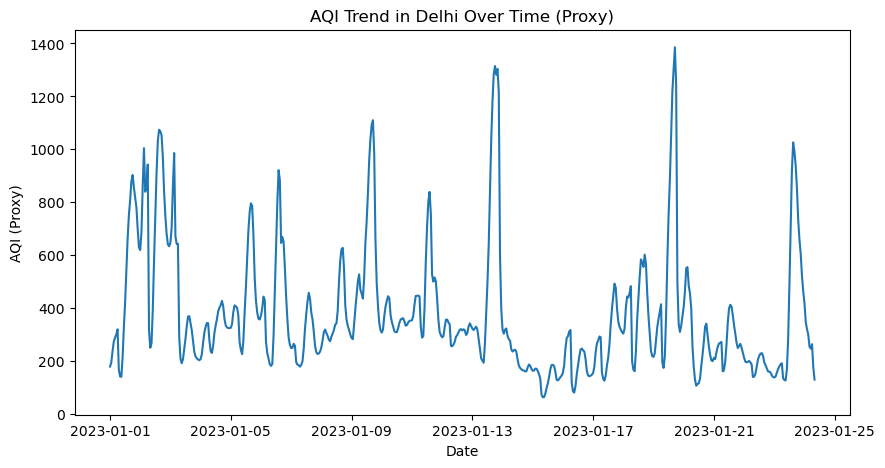

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['AQI_Proxy'])
plt.title("AQI Trend in Delhi Over Time (Proxy)")
plt.xlabel("Date")
plt.ylabel("AQI (Proxy)")
plt.show()

In [21]:
df['Month'] = df['date'].dt.month
monthly_aqi = df.groupby('Month')['AQI_Proxy'].mean()
monthly_aqi

Month
1    383.349184
Name: AQI_Proxy, dtype: float64

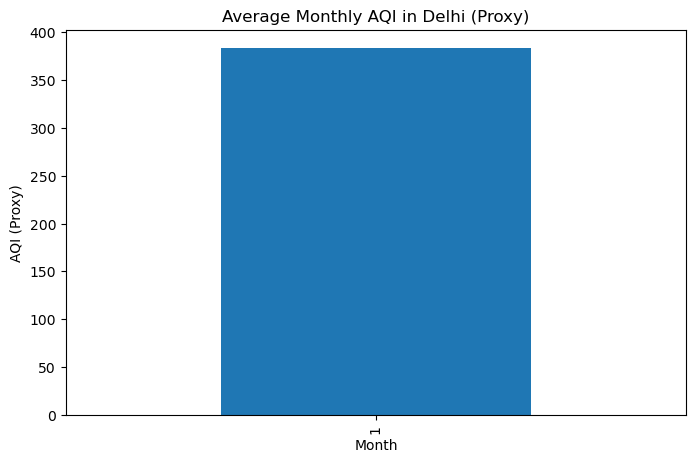

In [22]:
monthly_aqi.plot(kind='bar', figsize=(8,5))
plt.title("Average Monthly AQI in Delhi (Proxy)")
plt.xlabel("Month")
plt.ylabel("AQI (Proxy)")
plt.show()

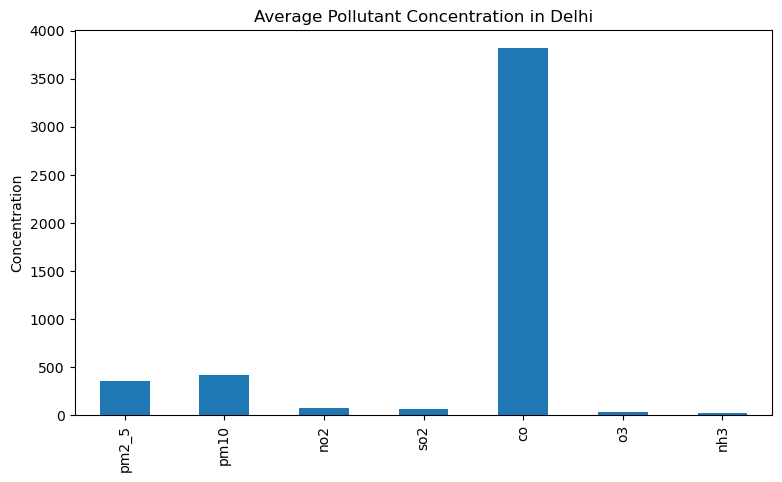

In [23]:
pollutants = ['pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3']
df[pollutants].mean().plot(kind='bar', figsize=(9,5))
plt.title("Average Pollutant Concentration in Delhi")
plt.ylabel("Concentration")
plt.show()

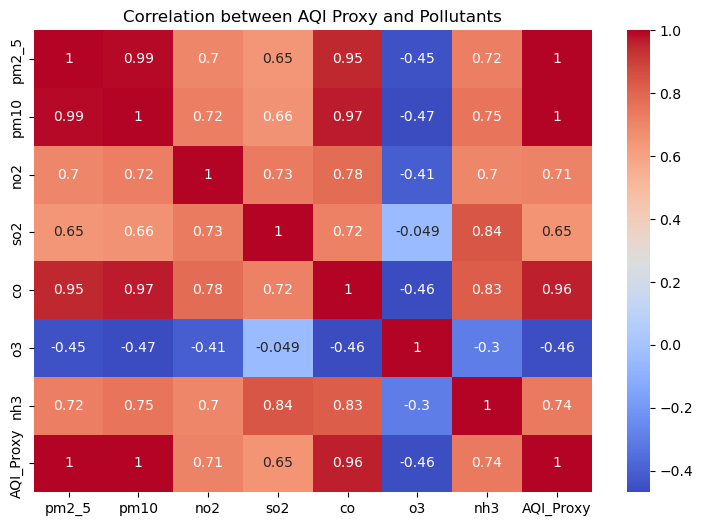

In [24]:
plt.figure(figsize=(9,6))
sns.heatmap(df[pollutants + ['AQI_Proxy']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between AQI Proxy and Pollutants")
plt.show()

In [26]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon',
    9: 'Post-Monsoon', 10: 'Post-Monsoon', 11: 'Post-Monsoon'
}

df['Season'] = df['Month'].map(season_map)

In [27]:
df.groupby('Season')['AQI'].mean().plot(kind='bar')
plt.title("Season-wise AQI in Delhi")
plt.ylabel("AQI")
plt.show()

KeyError: 'Column not found: AQI'